In [4]:
# 1. Data Preparation

import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("../data/q2_customers.csv")

# Keep a copy for later
df_original = df.copy()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Convert back to DataFrame (important for readability later)
X_scaled = pd.DataFrame(X_scaled, columns=df.columns)

X_scaled.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


Feature scaling is essential before applying K-Means because the algorithm relies on distance calculations. Features with larger magnitudes (such as annual spend) would dominate the clustering process if data is not scaled. StandardScaler ensures that all features contribute equally by transforming them to have mean 0 and standard deviation 1, resulting in more meaningful and balanced clusters.

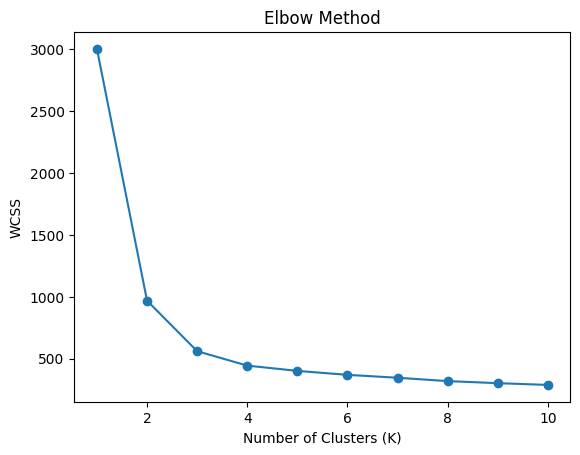

In [5]:
# 2. Choosing K — Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  # inertia = WCSS

# Plot
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

The elbow plot shows a sharp decrease in WCSS up to K = X, after which the rate of decrease slows significantly. This indicates diminishing returns in cluster compactness. Therefore, K = X is selected as the optimal number of clusters.

In [9]:
# 3. K-Means Clustering
# Fit K-Means with your chosen K
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters

centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]  # exclude cluster column
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


Cluster 0 (Young Frequent Low-Spenders):
Customers in this cluster are young (~25 years) with low annual spend (~14.8K) but very frequent visits (~14 visits/month) and small basket sizes (~559). They also have very recent engagement (~9 days since last visit) and purchase from few categories (~2).
Conclusion: 
These are highly active but low-value customers, likely making small, frequent purchases. They can be targeted with upselling, bundle offers, and category expansion strategies.

Cluster 1 (Dormant High-Spenders / Inactive Explorers):
Customers here are older (~57 years) with very high annual spend (~89.4K) but very low visit frequency (~2.5 visits/month) and long inactivity (~105 days since last visit). They have large basket sizes (~5530) and purchase across many categories (~7.5).
Conclusion:
These are previously high-value but currently inactive customers. They represent a churn risk and should be targeted with re-engagement campaigns, personalized offers, and win-back strategies.

Cluster 2 (Balanced Mid-Value Customers):
Customers in this cluster are middle-aged (~40 years) with moderate annual spend (~43.3K), moderate visit frequency (~8 visits/month), and medium basket sizes (~2022). Their recency (~35 days) and category diversity (~4.4) are also moderate.
Conclusion:
These are stable, mid-value customers with consistent behavior. They can be targeted with loyalty programs, cross-selling, and retention strategies to increase lifetime value.

In [12]:
# 4. Dimensionality Reduction with PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

loadings

Explained Variance Ratio: [0.83560354 0.05568764]


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


PCA Component Interpretation

Principal Component 1 (PC1): Overall Customer Value & Engagement
PC1 has strong positive loadings on annual spend, basket size, age, number of categories purchased, and days since last visit, and a negative loading on visits per month.
This component captures a spectrum from high-value, less frequent shoppers (older customers who spend more per visit and purchase across categories) to low-spend, frequent shoppers.
In business terms, PC1 represents overall customer value and purchasing power vs. frequency-driven behavior.

Principal Component 2 (PC2): Recency-Driven Behavior (Inactivity vs Activity)
PC2 is dominated by a very high positive loading on days since last visit (~0.91), with relatively smaller contributions from other features.
This component primarily captures customer recency, distinguishing inactive/dormant customers (high days since last visit) from recently active customers.
In business terms, PC2 represents customer engagement recency and churn risk.

__Key Insight:__
PC1 (~83.6% variance) explains most of the variation and reflects customer value and behavior patterns
PC2 (~5.6% variance) adds insight into recency and inactivity

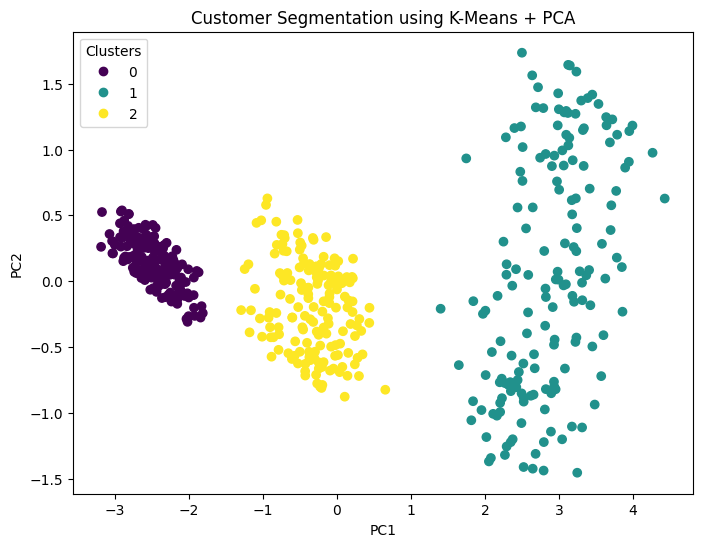

In [13]:
# 5. Cluster Visualisation 
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=df['cluster'],
    cmap='viridis'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segmentation using K-Means + PCA")

plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()